<a href="https://colab.research.google.com/github/mukund1040/Data-Analytics-Projects/blob/main/01-Student-Performance-Analysis/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Analysis

## Project Objective

The objective of this project is to analyze student exam performance
and identify patterns related to subjects, gender, test preparation,
parental education, and lunch type.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/NadavKiani/Students-Performance-in-Exams/master/StudentsPerformance.csv"

df = pd.read_csv(url)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Understand your dataset





In [ ]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
df.shape

(1000, 8)

In [ ]:
df.columns


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


# Data Cleaning

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df["gender"].unique()

array(['female', 'male'], dtype=object)

In [ ]:
df["lunch"].unique()

array(['standard', 'free/reduced'], dtype=object)

In [ ]:
df["test preparation course"].unique()

array(['none', 'completed'], dtype=object)

In [ ]:
df[["math score", "reading score", "writing score"]].min()

,0
math score,0
reading score,17
writing score,10


In [ ]:
df[["math score", "reading score", "writing score"]].max()

,0
math score,100
reading score,100
writing score,100


In [ ]:
df["average_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


# Find the top-performing students

In [ ]:
df.sort_values("average_score", ascending=False).head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.000000
962,female,group E,associate's degree,standard,none,100,100,100,100.000000
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667
712,female,group D,some college,standard,none,98,100,99,99.000000
179,female,group D,some high school,standard,completed,97,100,100,99.000000
165,female,group C,bachelor's degree,standard,completed,96,100,100,98.666667
625,male,group D,some college,standard,completed,100,97,99,98.666667
685,female,group E,master's degree,standard,completed,94,99,100,97.666667
903,female,group D,bachelor's degree,free/reduced,completed,93,100,100,97.666667


In [ ]:
df["average_score"].max()

100.0

In [ ]:
df["average_score"].mean()

np.float64(67.77066666666666)

## Compare subjects

In [ ]:
df[["math score", "reading score", "writing score"]].mean()

,0
math score,66.089
reading score,69.169
writing score,68.054


# Gender analysis

In [ ]:
df.groupby("gender")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


# Test preparation analysis

In [ ]:
df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


# **Visualization.**

## Create your first chart 📊

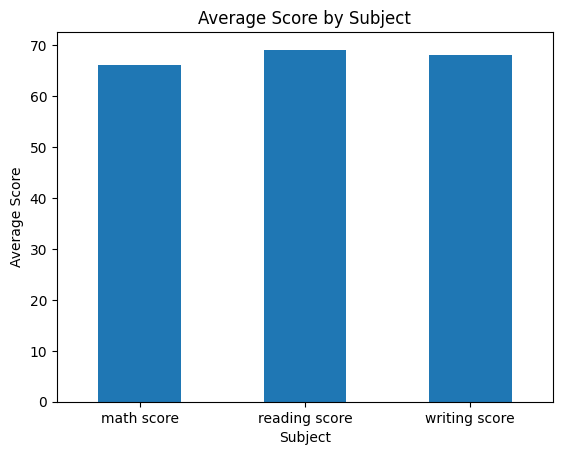

In [ ]:
import matplotlib.pyplot as plt

subject_means = df[["math score", "reading score", "writing score"]].mean()

subject_means.plot(kind="bar")

plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()

# Gender comparison chart

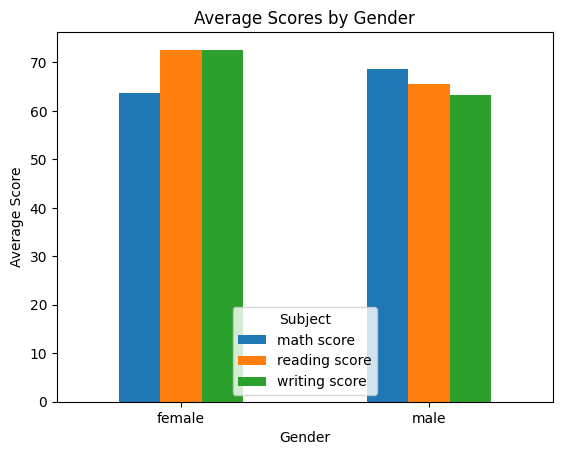

In [ ]:
gender_scores = df.groupby("gender")[[
    "math score",
    "reading score",
    "writing score"
]].mean()

gender_scores.plot(kind="bar")

plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")
plt.show()

# Test preparation visualization

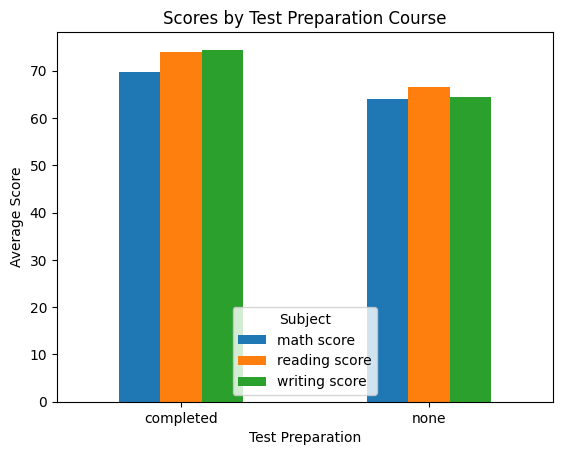

In [ ]:
prep_scores = df.groupby("test preparation course")[
    ["math score", "reading score", "writing score"]
].mean()

prep_scores.plot(kind="bar")

plt.title("Scores by Test Preparation Course")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")
plt.show()

# Distribution of average scores

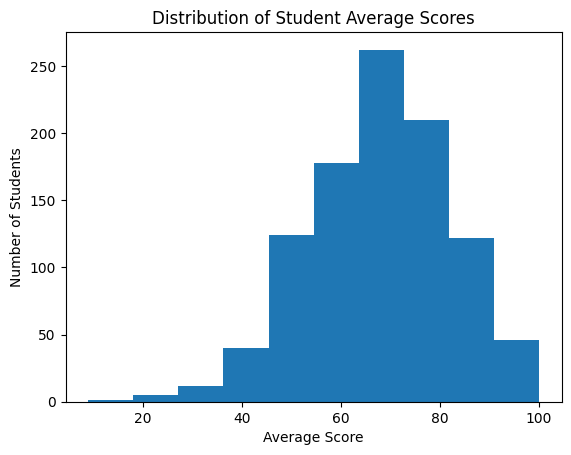

In [ ]:
plt.hist(df["average_score"], bins=10)

plt.title("Distribution of Student Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Number of Students")
plt.show()

In [ ]:
df["performance"] = df["average_score"].apply(
    lambda x: "Needs Attention" if x < 40 else "Other"
)
df["performance"].value_counts()

,count
performance,
Other,970
Needs Attention,30


# Save your cleaned dataset

In [ ]:
df.to_csv("student_performance_cleaned.csv", index=False)

In [ ]:
import os

os.listdir()


['.config', 'student_performance_cleaned.csv', 'sample_data']

# Key Insights


### 1. Overall Performance:

In [ ]:
df["average_score"].mean()

np.float64(67.77066666666666)

In [ ]:
df["average_score"].median()

68.33333333333333

In [ ]:
df["average_score"].min(), df["average_score"].max()

(9.0, 100.0)

### 2. Highest-Scoring Subject:

In [ ]:
df[["math score", "reading score", "writing score"]].mean()

,0
math score,66.089
reading score,69.169
writing score,68.054


In [ ]:
df[["math score", "reading score", "writing score"]].mean().sort_values(ascending=False)

,0
reading score,69.169
writing score,68.054
math score,66.089


### 3. Gender Comparison:

In [ ]:
df.groupby("gender")["average_score"].mean()

,average_score
gender,
female,69.569498
male,65.837483


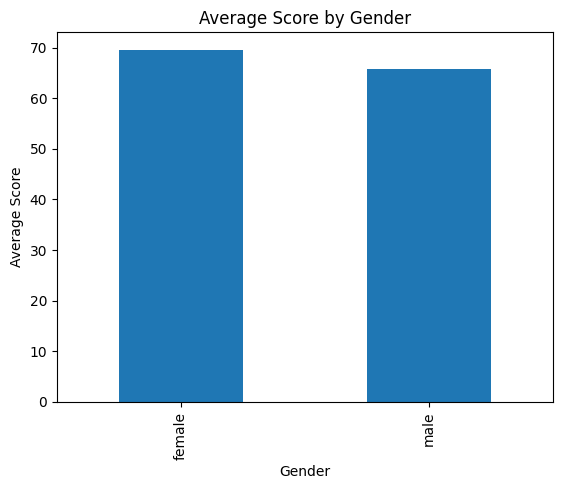

In [ ]:
df.groupby("gender")["average_score"].mean().plot(kind="bar")

plt.title("Average Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.show()

### 4. Test Preparation:

In [ ]:
df.groupby("test preparation course")["average_score"].mean()

,average_score
test preparation course,
completed,72.669460
none,65.038941


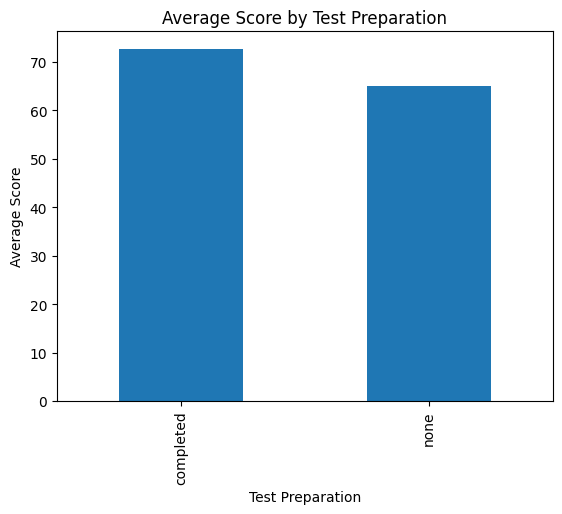

In [ ]:
df.groupby("test preparation course")["average_score"].mean().plot(kind="bar")

plt.title("Average Score by Test Preparation")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")
plt.show()

### 5. Parental Education:

In [ ]:
df.groupby("parental level of education")["average_score"].mean().sort_values(ascending=False)

,average_score
parental level of education,
master's degree,73.598870
bachelor's degree,71.923729
associate's degree,69.569069
some college,68.476401
some high school,65.108007
high school,63.096939


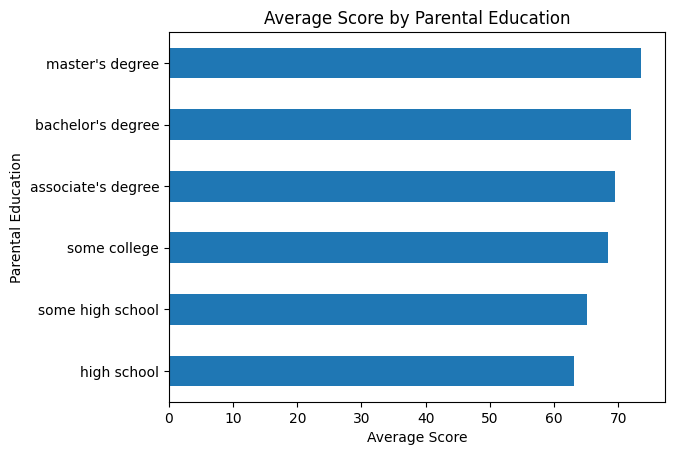

In [ ]:
df.groupby("parental level of education")["average_score"].mean().sort_values().plot(kind="barh")

plt.title("Average Score by Parental Education")
plt.xlabel("Average Score")
plt.ylabel("Parental Education")
plt.show()

### 6. Lunch Type:

In [ ]:
df.groupby("lunch")["average_score"].mean()

,average_score
lunch,
free/reduced,62.199061
standard,70.837209


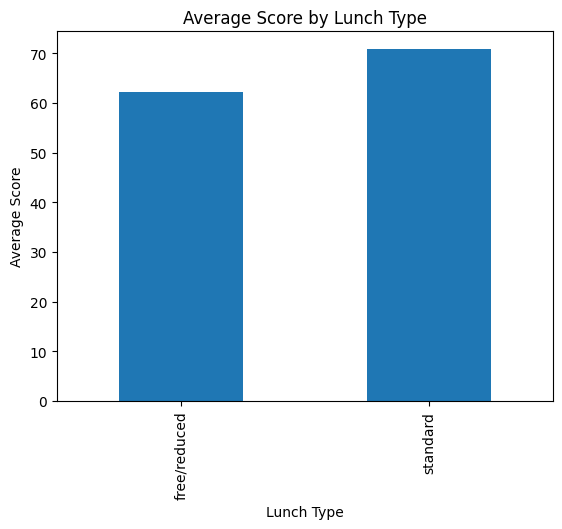

In [ ]:
df.groupby("lunch")["average_score"].mean().plot(kind="bar")

plt.title("Average Score by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.show()

### 7. Students Needing Attention:

In [ ]:
df["performance"].value_counts()

,count
performance,
Other,970
Needs Attention,30


In [ ]:
df["performance"].value_counts(normalize=True) * 100

,proportion
performance,
Other,97.0
Needs Attention,3.0


## Conclusion

This analysis explored student performance across mathematics,
reading, and writing. The analysis also examined how performance
varied across gender, test preparation, parental education, and
lunch type.

The analysis helped identify patterns in student performance and
demonstrated how Python and Pandas can be used to clean, analyze,
and visualize real-world data.